In [1]:
import numpy as np
from cq.numeric import *

D = 3
n = 5000

v, w = rand_ortho_pair(D+1, n)
T = hermfkin(v) + hermfkin(w)
rho = states_to_density(v, w)
gs = rho_to_g(rho)
gs, Ts = np.array(gs), np.array(T)

In [2]:
from sklearn.model_selection import train_test_split

X = np.column_stack([gs[:,1:], Ts]) #remove g_0 to avoid bias ruining implicit polynomial fit
X_train, X_test = train_test_split(X, test_size=0.3, random_state=42)

In [3]:
from sklearn.preprocessing import PolynomialFeatures
from sympy import *
from warnings import warn
from typing import Final, Self
from numpy.typing import NDArray

class ImplicitPolynomial:
    degree: Final[int]
    features: Final[PolynomialFeatures]
    coef: NDArray[np.float64]
    singular_values: NDArray[np.float64]
    
    def __init__(self, degree: int) -> None:
        self.degree = degree
        self.features = PolynomialFeatures(
            degree=degree,
            include_bias=True,
        )
    
    def fit(self, xyz: NDArray) -> Self:
        """
        Fit p(x, y, z) = 0 to points of shape (n_samples, n_features).
        """
        xyz = np.asarray(xyz, dtype=float)
        if xyz.ndim != 2:
            raise ValueError('malformed samples')
        
        A = self.features.fit_transform(xyz)
        if xyz.shape[0] <= self.features.powers_.shape[0]:
            warn(f'Less samples than coefficients to fit (coverage: {xyz.shape[0]/self.features.powers_.shape[0]})!', UserWarning, stacklevel=3)
        
        #full_matrices=len(xyz) < n ????
        #keep sigma for diagnostics
        _, self.singular_values, Vt = np.linalg.svd(A, full_matrices=False)
        zeros = sum(int(np.isclose(s, 0)) for s in self.singular_values)
        if zeros == 0:
            warn(f'Fit didn\'t converge: {self.singular_values[-1]}!', UserWarning, stacklevel=3)
        if zeros > 1:
            warn(f'Kernel dimensionality {zeros}; solution is not unique!', UserWarning, stacklevel=3)
        self.coef = Vt[-1]
        return self
    
    def __call__(self, xyz: NDArray) -> NDArray:
        """
        Evaluate p(x, y, z). Points on the fitted surface give values near zero.
        """
        A = self.features.transform(np.asarray(xyz, dtype=float))
        return A @ self.coef
    
    #Claude
    def reduce(self, xy: NDArray) -> NDArray:
        xy = np.asarray(xy, dtype=float)
        if not (xy.ndim==2 and xy.shape[1]==self.features.n_features_in_-1):
            raise ValueError('wrong shape')
        
        # evaluating at z=1 leaves exactly the monomials in the other variables
        monomials = self.coef * self.features.transform(
                np.column_stack([xy, np.ones(len(xy))]))
        degrees = self.features.powers_[:, -1]
        return np.stack([monomials[:, degrees==k].sum(axis=1)
                for k in range(self.degree+1)], axis=-1)
    
    def items(self) -> Generator[tuple[tuple[int,...],float]]:
        for k, v in zip(self.features.powers_, self.coef, strict=True):
            yield tuple(k), v
    
    def to_sympy(self, *gens: Symbol, trim: bool=True) -> Poly:
        return Poly.from_dict({
            k: v for k, v in self.items()
            if not trim or not np.isclose(v, 0)
        }, *gens)

for d in range(1, 3+1):
    p = ImplicitPolynomial(d)
    p.fit(X_train)
    print('Degree', d, ' std:', np.std(p(X_test)))
    with np.printoptions(precision=1, suppress=False):
        print(p.singular_values)

Degree 1  std: 0.15789871293947902
[454.8 166.2  60.1  47.1  41.2  24.4  20.3   9.3]
Degree 2  std: 0.01762350684877147
[3.5e+03 1.2e+03 5.6e+02 4.8e+02 3.2e+02 2.8e+02 1.9e+02 1.8e+02 1.4e+02
 1.2e+02 1.0e+02 9.7e+01 7.2e+01 5.5e+01 5.3e+01 4.3e+01 3.9e+01 3.5e+01
 3.0e+01 2.5e+01 2.3e+01 2.2e+01 1.9e+01 1.8e+01 1.4e+01 1.4e+01 9.1e+00
 7.8e+00 7.8e+00 6.5e+00 4.6e+00 4.1e+00 3.6e+00 2.7e+00 2.2e+00 1.0e+00]
Degree 3  std: 1.822850245309116e-14
[2.8e+04 8.6e+03 4.3e+03 4.0e+03 2.5e+03 2.0e+03 1.5e+03 1.5e+03 1.4e+03
 1.1e+03 8.9e+02 7.2e+02 6.8e+02 6.6e+02 4.4e+02 4.3e+02 3.8e+02 3.7e+02
 3.3e+02 3.3e+02 2.8e+02 2.6e+02 2.2e+02 1.9e+02 1.9e+02 1.7e+02 1.6e+02
 1.5e+02 1.3e+02 1.3e+02 1.1e+02 1.1e+02 1.0e+02 9.0e+01 8.4e+01 8.3e+01
 7.8e+01 7.4e+01 7.0e+01 6.5e+01 6.3e+01 5.8e+01 5.7e+01 5.5e+01 5.0e+01
 4.9e+01 4.7e+01 4.4e+01 3.9e+01 3.8e+01 3.7e+01 3.4e+01 3.0e+01 3.0e+01
 2.8e+01 2.7e+01 2.5e+01 2.5e+01 2.4e+01 2.3e+01 2.3e+01 2.2e+01 2.1e+01
 2.0e+01 1.8e+01 1.8e+01 1.6e+01 1.5e+0

C:\Users\S.Goessl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\interactiveshell.py:3701: UserWarning: Fit didn't converge: 9.266981835998232!
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\S.Goessl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\interactiveshell.py:3701: UserWarning: Fit didn't converge: 1.0282711250707144!
  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
syms = (*symbols('g1:7'), Symbol('T')) #g1 g2 g3 g4 g5 g6 T
poly = p.to_sympy(*syms)
poly

Poly(-0.00334425770169655*g1**3 + 0.0116049436613879*g1**2*g3 - 0.00854805177938711*g1**2*g5 - 0.0342786414413463*g1*g2**2 + 0.0946095961284357*g1*g2*g4 - 0.0740282999370489*g1*g2*g6 + 0.0567539351714797*g1*g2*T - 0.12060211223944*g1*g2 - 0.0117049019557624*g1*g3**2 + 0.0164515726212596*g1*g3*g5 - 0.0535081232254574*g1*g4**2 + 0.0537306111838822*g1*g4*g6 + 0.0163834498749948*g1*g4*T - 0.0300363247708416*g1*g4 - 0.00535081232258345*g1*g5**2 + 0.00535081232264249*g1*g6**2 - 0.089735850660846*g1*g6*T + 0.206392456519562*g1*g6 + 0.060196638628575*g1*T**2 - 0.361179831770933*g1*T + 0.459835433967362*g1 - 0.0170660936192507*g2**2*g3 + 0.0433508340234122*g2**2*g5 - 0.00709424189657209*g2*g3*g4 + 0.0582851447266097*g2*g3*g6 - 0.1100560608022*g2*g3*T + 0.269347727752677*g2*g3 - 0.0528773570979109*g2*g4*g5 - 0.0320514141986261*g2*g5*g6 + 0.139884347343887*g2*g5*T - 0.316898490587578*g2*g5 + 0.00341321872390529*g3**3 - 0.00732690152514077*g3**2*g5 + 0.0163834498745587*g3*g4**2 - 0.038885535286147

In [5]:
poly = Poly(poly, Symbol('T'))
poly

Poly((0.060196638628575*g1 - 0.0879228183003594*g5)*T**2 + (0.0567539351714797*g1*g2 + 0.0163834498749948*g1*g4 - 0.089735850660846*g1*g6 - 0.361179831770933*g1 - 0.1100560608022*g2*g3 + 0.139884347343887*g2*g5 + 0.0200655462093207*g3*g4 + 0.0622786629637078*g3*g6 + 0.229368298244013*g3 - 0.0897358506604027*g4*g5 + 0.0360435897235645*g5*g6 + 0.117230424399292*g5)*T - 0.00334425770169655*g1**3 + 0.0116049436613879*g1**2*g3 - 0.00854805177938711*g1**2*g5 - 0.0342786414413463*g1*g2**2 + 0.0946095961284357*g1*g2*g4 - 0.0740282999370489*g1*g2*g6 - 0.12060211223944*g1*g2 - 0.0117049019557624*g1*g3**2 + 0.0164515726212596*g1*g3*g5 - 0.0535081232254574*g1*g4**2 + 0.0537306111838822*g1*g4*g6 - 0.0300363247708416*g1*g4 - 0.00535081232258345*g1*g5**2 + 0.00535081232264249*g1*g6**2 + 0.206392456519562*g1*g6 + 0.459835433967362*g1 - 0.0170660936192507*g2**2*g3 + 0.0433508340234122*g2**2*g5 - 0.00709424189657209*g2*g3*g4 + 0.0582851447266097*g2*g3*g6 + 0.269347727752677*g2*g3 - 0.0528773570979109*g2

In [6]:
print(p(X_test[:10]))
np.std(p(X_test))

[9.70334924e-14 1.40332190e-13 9.21485110e-14 1.07025500e-13
 1.16795462e-13 1.07469589e-13 1.43884904e-13 1.11688436e-13
 1.30326305e-13 1.15907284e-13]


np.float64(1.822850245309116e-14)

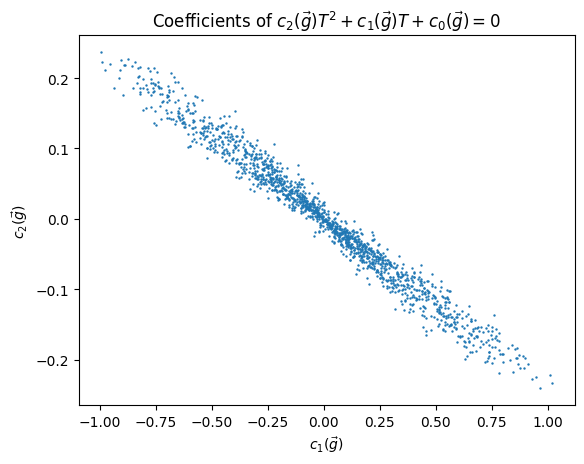

In [7]:
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

fig, ax = plt.subplots()

r = p.reduce(X_test[:,:-1]) #polynomials just in T
assert np.allclose(r[:,-1], 0)

plt.scatter(r[:,1], r[:,2], marker='o', s=(72./fig.dpi)**2)
plt.title(r'Coefficients of $c_2(\vec{g})T^2+c_1(\vec{g})T+c_0(\vec{g})=0$')
plt.xlabel(r'$c_1(\vec{g})$')
plt.ylabel(r'$c_2(\vec{g})$')
plt.show()

---

In [8]:
p = ImplicitPolynomial(4)
p.fit(X_train)
print(np.std(p(X_test)))
with np.printoptions(precision=1, suppress=False):
    print(p.singular_values)

4.355109290204093e-13
[2.3e+05 5.9e+04 3.5e+04 2.9e+04 2.0e+04 1.6e+04 1.2e+04 1.1e+04 9.9e+03
 8.3e+03 6.6e+03 5.7e+03 5.2e+03 5.0e+03 4.4e+03 3.1e+03 3.1e+03 2.8e+03
 2.7e+03 2.5e+03 2.3e+03 2.1e+03 2.0e+03 1.8e+03 1.5e+03 1.4e+03 1.4e+03
 1.1e+03 1.1e+03 1.1e+03 1.1e+03 9.9e+02 9.6e+02 9.4e+02 8.3e+02 8.2e+02
 8.1e+02 7.6e+02 6.7e+02 6.2e+02 6.1e+02 5.6e+02 5.4e+02 4.9e+02 4.8e+02
 4.5e+02 4.5e+02 4.4e+02 4.1e+02 4.0e+02 3.9e+02 3.8e+02 3.5e+02 3.4e+02
 3.3e+02 3.1e+02 2.8e+02 2.7e+02 2.7e+02 2.6e+02 2.5e+02 2.4e+02 2.3e+02
 2.3e+02 2.3e+02 2.0e+02 2.0e+02 1.9e+02 1.9e+02 1.9e+02 1.8e+02 1.7e+02
 1.6e+02 1.6e+02 1.5e+02 1.5e+02 1.4e+02 1.4e+02 1.3e+02 1.3e+02 1.2e+02
 1.2e+02 1.1e+02 1.1e+02 1.1e+02 1.0e+02 9.9e+01 9.6e+01 9.4e+01 9.2e+01
 9.0e+01 8.3e+01 8.2e+01 7.9e+01 7.4e+01 7.2e+01 7.0e+01 6.8e+01 6.7e+01
 6.7e+01 6.5e+01 6.1e+01 5.8e+01 5.7e+01 5.6e+01 5.5e+01 5.4e+01 5.3e+01
 5.3e+01 5.0e+01 4.8e+01 4.7e+01 4.6e+01 4.4e+01 4.3e+01 4.2e+01 4.1e+01
 3.9e+01 3.9e+01 3.8e+01 3.7e

C:\Users\S.Goessl\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\interactiveshell.py:3701: UserWarning: Kernel dimensionality 27; solution is not unique!
  exec(code_obj, self.user_global_ns, self.user_ns)


In [9]:
poly = p.to_sympy(*syms)
poly

Poly(0.00076534069461821*g1**4 + 0.0024213803492549*g1**3*g2 - 0.00249342893314813*g1**3*g3 - 0.0030779922262498*g1**3*g4 + 0.0026713569620271*g1**3*g5 - 0.00117046866128074*g1**3*g6 + 0.0063627755153674*g1**3*T - 0.0105687227593919*g1**3 + 0.0123355628781317*g1**2*g2**2 - 0.000179756562522112*g1**2*g2*g3 - 0.0339557532700108*g1**2*g2*g4 - 0.00188837934576804*g1**2*g2*g5 + 0.0237112993309796*g1**2*g2*g6 - 0.0225908384740005*g1**2*g2*T + 0.0538394165652812*g1**2*g2 + 0.000230429703481871*g1**2*g3**2 - 0.00185743313351223*g1**2*g3*g4 - 0.000651053437115712*g1**2*g3*g5 + 0.0131082974796148*g1**2*g3*g6 - 0.0287190805168084*g1**2*g3*T + 0.0562642523176619*g1**2*g3 + 0.0184989581435205*g1**2*g4**2 + 0.00438761987989745*g1**2*g4*g5 - 0.0101953372321133*g1**2*g4*g6 - 0.00682645889216524*g1**2*g4*T - 0.000739587624927193*g1**2*g4 - 0.00115217865959561*g1**2*g5**2 - 0.0111403463845008*g1**2*g5*g6 + 0.0208463252160863*g1**2*g5*T - 0.0437263276847126*g1**2*g5 - 0.0122778771488183*g1**2*g6**2 + 0.0

In [10]:
poly = Poly(poly, Symbol('T'))
poly

Poly(0.00865102824785163*T**4 + (0.0489043612829118*g1 + 0.00788485503595709*g2 - 0.00805151557710711*g3 - 0.0150238797646768*g4 - 0.0483780250546049*g5 + 0.0115482418025402*g6 - 0.0548818077007142)*T**3 + (-0.0196970689914305*g1**2 + 0.0386370743177117*g1*g2 + 0.00345055701417989*g1*g3 + 2.56013674731692e-5*g1*g4 + 0.0124684539735308*g1*g5 - 0.0483946797075574*g1*g6 - 0.254465940534117*g1 + 0.00187804831719766*g2**2 - 0.0542523322596137*g2*g3 - 0.00605807023098855*g2*g4 + 0.0539826843037536*g2*g5 + 0.00346157785057495*g2*g6 - 0.0413068602211559*g2 - 0.00727810354673861*g3**2 + 0.0198366321206728*g3*g4 + 0.00798693028962235*g3*g5 + 0.00840693243390796*g3*g6 + 0.162504519452031*g3 + 0.000195869452798652*g4**2 - 0.0321259002440398*g4*g5 + 0.00922910730337793*g4*g6 + 0.0932894616712965*g4 + 0.0284190702186923*g5**2 + 0.024133772168836*g5*g6 + 0.0262013155799087*g5 - 0.00453662662354313*g6**2 - 0.108900478157555*g6 + 0.120961755258809)*T**2 + (0.0063627755153674*g1**3 - 0.0225908384740005*

In [11]:
p.coef /= p.coef[-1]
poly = Poly(p.to_sympy(*syms), Symbol('T'))
#print(Poly(poly.as_expr().evalf(2), Symbol('T'))._repr_latex_())
poly

Poly(1.0*T**4 + (5.65301139723553*g1 + 0.911435590088981*g2 - 0.930700414613327*g3 - 1.73665827162312*g4 - 5.59217051066952*g5 + 1.33489817298979*g6 - 6.34396352992413)*T**3 + (-2.27684714777367*g1**2 + 4.46618288725468*g1*g2 + 0.398860911711483*g1*g3 + 0.00295934387678447*g1*g4 + 1.44126843842258*g1*g5 - 5.59409567522516*g1*g6 - 29.4145312260783*g1 + 0.217089606390322*g2**2 - 6.27120045216435*g2*g3 - 0.700271696892563*g2*g4 + 6.24003098327179*g2*g5 + 0.400134845408069*g2*g6 - 4.77479197127971*g2 - 0.841299246542864*g3**2 + 2.29297969586435*g3*g4 + 0.923234794847168*g3*g5 + 0.971784184844815*g3*g6 + 18.7844166954821*g3 + 0.0226411759604755*g4**2 - 3.7135354692684*g4*g5 + 1.06682200531132*g4*g6 + 10.7836269861289*g4 + 3.28505114126171*g5**2 + 2.78969984577605*g5*g6 + 3.02869379560926*g5 - 0.524403168452229*g6**2 - 12.588154267627*g6 + 13.9823558302273)*T**2 + (0.735493554416207*g1**3 - 2.61134720946157*g1**2*g2 - 3.31973029032016*g1**2*g3 - 0.789092197665695*g1**2*g4 + 2.40969334729235*

In [12]:
print(p(X_test[:10]))
np.std(p(X_test))

[-1.51736401e-11  2.71711542e-11 -3.60529384e-11 -1.17097443e-11
  4.81970019e-11  7.80353560e-12  1.08848042e-10 -2.22968310e-11
  2.27373675e-13  1.56763491e-11]


np.float64(5.031941900537575e-11)